# Capstone — Primer análisis exploratorio

**¿Es igual de difícil clasificar a un campeonato nadando en piscina de 25 m o de 50 m?**

Felipe Leiva y Javier Fuentes · Diplomado en Ciencia de Datos Aplicada, UTFSM
Módulo 1, evaluación 2 · Entrega: martes 15 de septiembre de 2026

---

## La pregunta

El mismo nadador va más rápido en piscina de 25 m que en una de 50 m, porque da el
doble de vueltas y cada vuelta regala tiempo: empuja la pared y viaja bajo el agua,
que es más rápido que nadar en superficie. La razón entre ambas marcas es el
**factor de conversión**:

$$\text{factor} = \frac{t_{50\text{m}}}{t_{25\text{m}}}$$

**Pregunta:** ¿es constante ese factor, o depende del estilo, la distancia y el sexo?

**Hipótesis verificable:** si la ventaja de la piscina corta viniera *solo* de dar
más vueltas y cada vuelta valiera lo mismo, la diferencia entre piscinas sería
proporcional a las vueltas extra (`distancia / 50`) y el factor sería el mismo en
todas las pruebas. Si el factor cambia sistemáticamente por estilo, la hipótesis
del "modelo simple" queda descartada.

**Por qué importa:** World Aquatics acepta marcas de ambas piscinas para clasificar
a un campeonato, con **dos tablas de mínimas separadas**. La razón entre esas dos
exigencias es la equivalencia que la federación aplica de hecho. Si no coincide con
la real, clasificar es más difícil en una piscina que en la otra, y cuánto depende
de la prueba.

## Los datos

Rankings de la temporada 2024 de la API pública de World Aquatics
(`https://api.worldaquatics.com/fina/rankings/swimming`), 12 pruebas × 2 sexos ×
2 piscinas x 12 meses= 567 consultas en modo `BEST_TIMES` (la mejor marca del mes de cada
nadador por a{p}). El script `descarga_temporadas.py`, es necesario agregar --femenino o --masculino para el correcto funcionamiento, de este mismo directorio las reproduce.

> **Nota sobre los datos, que no se pueden compartir.** `datos/nadosFull_femenino.csv` y `datos/nadosFull_masculino.csv` como la tabla de pares `datos/pares_lcm_scm.csv` **no se adjuntan ni se
> versionan**: los términos legales de World Aquatics prohíben en su sección 3 la
> redistribución de sus contenidos. Se declara aquí, como pide el enunciado.
>
> **Cómo obtenerlos:** `uv run python capstone/descarga_temporadas.py` --femenino ó --masculino desde `~/diplomado-cdd`.
> Son 567 consultas a la API con medio segundo de pausa entre ellas —unos minutos la
> primera vez— y el script cachea cada respuesta, así que una segunda corrida no
> vuelve a pedir nada. A partir de ahí, este notebook reconstruye todo lo demás.
>
> Sí van en el repositorio las **tablas agregadas** que el notebook lee o produce
> (`datos/comparacion_wa.csv`, `factores_por_prueba.csv`, `factor_por_nivel.csv`,
> `metadatos.md`): son estadísticas por prueba, no contienen marcas individuales y
> por lo tanto no redistribuyen el contenido de la fuente.

## Qué contiene la entrega y en qué orden se ejecuta

La entrega es este repositorio. **El notebook se ejecuta de principio a fin sin
correr nada más**, siempre que existan los tres archivos que lee: `datos/nadosFull_masculino.csv`, `datos/nadosFull_femenino.csv`
(ver la nota de arriba) y `datos/comparacion_wa.csv` (incluido). Los scripts
auxiliares están para reproducir esos dos archivos desde cero:

| Orden | Archivo | Qué hace |
|---|---|---|
| 1 | `descarga_temporadas.py` | Baja los rankings de la API de World Aquatics, se deben hacer dos descargas, ejecutando --femenino y --masculino (576 consultas, con caché y pausa) → `datos/nadosFull_femeninos.csv` / `datos/nadosFull_masculinos.csv` |
| 2 | `factor_implicito_wa.py` | Transcribe las marcas mínimas oficiales del Mundial de 25 m, calcula el factor implícito de la federación y su brecha contra el medido → `datos/comparacion_wa.csv` |
| 3 | **`03_eda_capstone.ipynb`** | **El entregable.** Lee esos dos archivos; todo lo demás lo calcula en el camino |

Fuera de ese flujo, como respaldo de lo que se afirma en el texto:
`nivel_y_factor.py` repite el chequeo de sesgo de selección de la sección 3.2 con
una segunda definición de nivel (por marca mínima en vez de percentil), y
`metadatos.py` genera la tabla de metadatos de las columnas. `01_exploracion.ipynb`
y `02_explorando.ipynb` son cuadernos de trabajo previos y **no forman parte de la
entrega**.


**Nota:** al momento de la entrega, falta actualizar los archivos de metadatos y readme para que sea coherente en un 100%, esto se debe a que mejoramos la base y pasamos de obtener los mejores 5000 nadadores por año en cada prueba, a tener el ranking mensual.

## Declaración de uso de IA

Se usó Claude (Anthropic) y ChatGPT (OpenAI) para explorar la documentación de la API, discutir el
diseño del análisis y revisar código. Los datos, las decisiones metodológicas y la
interpretación son de los autores, que pueden explicar cada parte de lo entregado.

---
# 1. Los datos y su calidad

**Objetivo de la sección:** cargar los rankings tal como vienen de la API, describir
su tamaño y sus tipos, y dejar por escrito cada problema de calidad encontrado y qué
se decidió hacer con él.

In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110

# Paleta Okabe-Ito: legible también para daltonismo
COLORES = {"FREESTYLE": "#0072B2", "BACKSTROKE": "#D55E00",
           "BREASTSTROKE": "#009E73", "BUTTERFLY": "#CC79A7",
           "MEDLEY": "#E69F00"}
NOMBRES = {"FREESTYLE": "Libre", "BACKSTROKE": "Espalda",
           "BREASTSTROKE": "Pecho", "BUTTERFLY": "Mariposa", "MEDLEY": "Combinado"}
GRIS = "#6E878D"
ORDEN = ["FREESTYLE", "BUTTERFLY", "MEDLEY", "BREASTSTROKE", "BACKSTROKE"]
masculino = pd.read_csv("datos/nadosFull_masculino.csv")
femenino = pd.read_csv("datos/nadosFull_femenino.csv")
print("Datos nadadores masculinos")
print("-"*20)
print(f"Filas: {len(masculino):,}   Columnas: {masculino.shape[1]}")

print(f"Número de nados registras por nadadores hombres: {len(masculino):,}")
print("-"*20)
print("Datos nadadores femeninos")
print("-"*20)
print(f"Filas: {len(femenino):,}   Columnas: {femenino.shape[1]}")

print(f"Número de nados registras por nadadores mujeres: {len(femenino):,}")
print("-"*20)
crudo = pd.concat([masculino, femenino], ignore_index=True)
print("Datos Agrupados")
print(f"Filas: {len(crudo):,}   Columnas: {crudo.shape[1]}")
print(f"Total de nados registras: {len(crudo):,}")
crudo.head(3)

Datos nadadores masculinos
--------------------
Filas: 225,560   Columnas: 25
Número de nados registras por nadadores hombres: 225,560
--------------------
Datos nadadores femeninos
--------------------
Filas: 198,968   Columnas: 25
Número de nados registras por nadadores mujeres: 198,968
--------------------
Datos Agrupados
Filas: 424,528   Columnas: 25
Total de nados registras: 424,528


,anio,sexo,piscina,distancia,estilo,prueba,rank,tiempo,tiempo_s,puntos_fina,nombre,person_id,fecha_nacimiento,edad,pais,pais_codigo,club,fecha,competencia,ciudad,medalla,record,result_id,event_id,discipline_id
0,2024,M,LCM,50,FREESTYLE,Men's 50m Freestyle,1,21.87,21.87,874.0,ANDREW Michael,236b1fd2-5a01-456f-9ec0-49cdce0344e6,1999-04-18T00:00:00,24.0,United States of America,USA,MA Swim Academy,2024-01-13T00:00:00,2024 TYR Pro Series TN,Knoxville,1.0,NaN,R1002301,a9dfad26-bc4d-41a5-aeb1-ace1ba5603a4,54f8e2e1-0506-47f3-bc16-14648cee1369
1,2024,M,LCM,50,FREESTYLE,Men's 50m Freestyle,2,21.90,21.90,870.0,KARTAVI Martin,0bbfd97b-1e3e-4edc-9f52-48cc31f90fe4,2004-03-09T00:00:00,19.0,Israel,ISR,No,2024-01-20T00:00:00,57th Challenge Geneve,Geneva,NaN,NaN,R1227034,540d23c4-6019-4626-aeee-51ed90a208d2,54f8e2e1-0506-47f3-bc16-14648cee1369
2,2024,M,LCM,50,FREESTYLE,Men's 50m Freestyle,3,22.03,22.03,855.0,MATOS RIBEIRO Diogo,c5109175-9dd7-45c9-b88c-7c7adbe6a985,2004-10-27T00:00:00,19.0,Portugal,POR,No,2024-01-27T00:00:00,24th LUX Euro Meet,Luxembourg,1.0,NaN,R1200925,13e9b544-148d-47b2-a4cf-973511652dc2,54f8e2e1-0506-47f3-bc16-14648cee1369


## 1.1 Tipos, faltantes y cardinalidad

*Objetivo: saber con qué tipo de variable estamos tratando en cada columna y dónde
hay ausencias, antes de calcular nada.*

In [80]:
resumen = pd.DataFrame({
    "tipo": crudo.dtypes.astype(str),
    "nulos": crudo.isna().sum(),
    "% nulos": (crudo.isna().mean() * 100).round(2),
    "distintos": crudo.nunique(),
})
resumen

,tipo,nulos,% nulos,distintos
anio,int64,0,0.00,1
sexo,object,0,0.00,2
piscina,object,0,0.00,2
distancia,int64,0,0.00,4
estilo,object,0,0.00,5
prueba,object,0,0.00,24
rank,int64,0,0.00,4988
tiempo,object,0,0.00,31360
tiempo_s,float64,0,0.00,31360
puntos_fina,float64,0,0.00,1020


Tres grupos de columnas, y conviene no confundirlos:

- **Las que no tienen ni un nulo** (`tiempo_s`, `distancia`, `estilo`,
  `puntos_fina`, `pais`): son el núcleo del análisis y llegan completas.
- **`person_id` y `result_id`** existe un nulo para cada caso, lo cual se eliminan estos registros.
- **`edad` y `fecha_nacimiento`, con 6,41% de nulos**: ausencia real. Hay nadadores
  sin fecha de nacimiento cargada.
- **`medalla` (93,29%) y `record` (99,59%)**: *no son datos faltantes*. Un nulo ahí
  significa "ese nado no ganó medalla" y "ese nado no fue récord". Tratarlos como
  faltantes e imputarlos sería un error de lectura del dominio.

In [81]:
print("Nadadores distintos :", f"{crudo['person_id'].nunique():,}")
print("Países              :", crudo["pais"].nunique())
print("Competencias        :", crudo["competencia"].nunique())
print("\nNados por sexo y piscina:")
print(crudo.groupby(["sexo", "piscina"]).size().unstack(fill_value=0).to_string())

Nadadores distintos : 71,514
Países              : 215
Competencias        : 307

Nados por sexo y piscina:
piscina     LCM    SCM
sexo                  
F        147716  51252
M        165264  60296


## 1.2 Faltantes disfrazados

*Objetivo: buscar ausencias que no se ven como `NaN`, que es el caso que la clase 2
advertía (códigos 999, −1, textos centinela).*

Encontramos dos.

In [82]:
print("Los 6 valores más frecuentes de 'club':")
print(crudo["club"].value_counts().head(6).to_string())
club_no = (crudo["club"] == "No").sum()
print(f"\nEl literal 'No' aparece {club_no:,} veces ({club_no/len(crudo):.1%} de las filas).")
print("No es un club: es el centinela con que la API marca 'sin club'.")

Los 6 valores más frecuentes de 'club':
club
No                           77083
Cetus Espoo                   1581
Hoi Tin Athletic Assn Ltd     1451
Москва                        1331
Limmat Sharks Zürich          1313
Санкт-Петербург               1291

El literal 'No' aparece 77,083 veces (18.2% de las filas).
No es un club: es el centinela con que la API marca 'sin club'.


In [83]:
fuera = crudo.loc[~crudo["edad"].between(8, 70) & crudo["edad"].notna(),
                ["nombre", "pais_codigo", "edad", "fecha_nacimiento"]]
print("Edad declarada:")
print(crudo["edad"].describe(percentiles=[.01, .5, .99]).round(1).to_string())
print(f"\nEdades fuera de un rango adulto humano posible para competencia:  {len(fuera)}")

print(fuera.head(10).to_string(index=False))


Edad declarada:
count    397315.0
mean         16.6
std           3.8
min           4.0
1%           10.0
50%          16.0
99%          29.0
max         119.0

Edades fuera de un rango adulto humano posible para competencia:  389
        nombre pais_codigo  edad    fecha_nacimiento
CAMERON Zahiem         CLB   7.0 2016-03-27T00:00:00
    MOABI Zibo         CLB   7.0 2016-07-03T00:00:00
 MCGOWAN Zamar         CLB   7.0 2016-11-09T00:00:00
NUMADA Ritsuki         CLB   7.0 2016-08-31T00:00:00
  MAKABI Dylan         CLB   7.0 2016-06-11T00:00:00
  ELLIOTT Rhys         CLB   7.0 2016-04-08T00:00:00
    SHARPE Sol         CLB   6.0 2017-07-06T00:00:00
   GRAHAM Amir         CLB   7.0 2016-11-30T00:00:00
BROWN Liam-Kai         CLB   7.0 2016-06-09T00:00:00
  DENNIS Aaron         CLB   5.0 2018-03-20T00:00:00


La información extraída corresponde al ranking mensual de los mejores tiempos registrados por prueba, no discrimina en competencias juveniles, profesionales ni senior, lo que generan registros menores a 7 años.
De igual forma, se registron edades superiores a los 100 años, lo que sin duda es un error de carga en el origen; las de 7 y 72
son implausibles para un ranking mundial. **Todas comparten el mismo
`pais_codigo` = `CLB`**, que no es un país sino otro centinela de la API — señal de
que estas filas vienen de un registro mal formado.

**Decisión:** `club == "No"` pasa a `NaN` y las edades fuera de \[8, 70\] pasan a
`NaN`. No se borran las filas: el resto de la fila (el tiempo, que es lo que nos
interesa) sigue siendo válido, y `edad` no entra en el cálculo del factor.

In [84]:
limpio = crudo.copy()
limpio["club"] = limpio["club"].replace("No", np.nan)
limpio = limpio.dropna(subset=["person_id", "result_id"])
limpio.loc[~limpio["edad"].between(8, 70), "edad"] = np.nan
print(f"'club' nulo tras la corrección: {limpio['club'].isna().mean():.1%}")
print(f"'edad' nula tras la corrección: {limpio['edad'].isna().mean():.2%}")

'club' nulo tras la corrección: 18.2%
'edad' nula tras la corrección: 6.50%


In [85]:
resumen_limpio = pd.DataFrame({
    "tipo": limpio.dtypes.astype(str),
    "nulos": limpio.isna().sum(),
    "% nulos": (limpio.isna().mean() * 100).round(2),
    "distintos": limpio.nunique(),
})
resumen_limpio

,tipo,nulos,% nulos,distintos
anio,int64,0,0.00,1
sexo,object,0,0.00,2
piscina,object,0,0.00,2
distancia,int64,0,0.00,4
estilo,object,0,0.00,5
prueba,object,0,0.00,24
rank,int64,0,0.00,4988
tiempo,object,0,0.00,31360
tiempo_s,float64,0,0.00,31360
puntos_fina,float64,0,0.00,1020


## 1.3 Duplicados

**Objetivo**: Dado que se obtuvo la información del ranking mensual utilizando `BEST_TIMES` del mes, es esperable que distintos nadadores tengan más de un registro por cada prueba y piscina.


In [86]:
llave = ["anio", "sexo", "distancia", "estilo", "piscina", "person_id"]
print("Total de Nadadores:", f"{len(limpio):,}")
print("Nadadores distintos :", f"{limpio['person_id'].nunique():,}")
print("Porcentaje de nadadores distintos:", f"{limpio['person_id'].nunique() / len(crudo) * 100:.2f}%")
repetidos = limpio[limpio.duplicated(subset=llave)]
print("Nadadores repetidos (mismo sexo, distancia, estilo, piscina y persona):", f"{len(repetidos):,}")


Total de Nadadores: 424,527
Nadadores distintos : 71,514
Porcentaje de nadadores distintos: 16.85%
Nadadores repetidos (mismo sexo, distancia, estilo, piscina y persona): 115,456


Visualizamos las repetidas

In [87]:
print("Visualizamos cuantas veces un nadador tiene más de un registro por distancia de competencia, estilo de nado y piscina en un año")
tabla=repetidos.pivot_table(
    index=["sexo", "estilo", "piscina"], columns="distancia", aggfunc="size", fill_value=0
)
tabla

Visualizamos cuantas veces un nadador tiene más de un registro por distancia de competencia, estilo de nado y piscina en un año


distancia                   50    100   200   400
sexo estilo       piscina                        
F    BACKSTROKE   LCM         0  3969  2167     0
                  SCM         0   828   428     0
     BREASTSTROKE LCM         0  3680  2211     0
                  SCM         0   559   255     0
     BUTTERFLY    LCM         0  4293  1418     0
                  SCM         0   746   207     0
     FREESTYLE    LCM      9068  7641  4969  2815
                  SCM      1788  1337   998   503
     MEDLEY       LCM         0     0  2469  1173
                  SCM         0     0   336   246
M    BACKSTROKE   LCM         0  3888  2137     0
                  SCM         0   786   408     0
     BREASTSTROKE LCM         0  4165  2361     0
                  SCM         0   789   391     0
     BUTTERFLY    LCM         0  5692  1824     0
                  SCM         0   837   260     0
     FREESTYLE    LCM      9046  8915  6014  3264
                  SCM      2128  1779  1243   555
     MEDLEY       LCM         0     0  2764  1423
                  SCM         0     0   445   238

Para futuros análisis la competencia de Estilo Libre (`FREESTYLE`) en todas sus distancias, tanto para hombres como mujeres, es la que nos otorga mayor información por nadador a lo largo de un año, al tener mayor cantidad de registros por prueba. Esto abre oportunidades para revisar la progresión de nadadores a lo largo del año, ver cuando llegan al mejor tiempo, cuando registran su peor tiempo, la distribución entre piscinas de pruebas por nadador, entre otros.  

In [88]:

ej = (
    repetidos[repetidos["nombre"] == "SANTOS Guilherme"]
    .groupby(["sexo", "distancia", "estilo", "piscina"])
    .size()
    .reset_index(name="cantidad")
)
print("Registros repetidos para el nadador SANTOS Guilherme:")
ej

Registros repetidos para el nadador SANTOS Guilherme:


,sexo,distancia,estilo,piscina,cantidad
0,M,50,FREESTYLE,LCM,4
1,M,50,FREESTYLE,SCM,1
2,M,100,FREESTYLE,LCM,3
3,M,100,FREESTYLE,SCM,1


In [89]:

llave_agrupada = [
    "person_id",
    "sexo",
    "distancia",
    "estilo",
    "piscina"
]

estadisticas = (
    limpio
    .groupby(llave_agrupada)["tiempo_s"]
    .agg(
        veces="size",
        tiempo_promedio="mean",
        tiempo_mediana="median",
        tiempo_std="std",
        tiempo_peor="max"
    )
    .reset_index()
)

# Obtención del mejor tiempo
idx_mejor = (
    limpio
    .groupby(llave_agrupada)["tiempo_s"]
    .idxmin()
)

# Nos quedamos con TODA la información de la fila del mejor tiempo
sin_duplicados = limpio.loc[idx_mejor].copy()

# Agregamos las estadísticas
sin_duplicados = sin_duplicados.merge(
    estadisticas,
    on=llave_agrupada,
    how="left"
)

sin_duplicados = sin_duplicados.reset_index(drop=True)

In [90]:
ej = (sin_duplicados[sin_duplicados["nombre"] == "SANTOS Guilherme"]
      .groupby(["sexo", "distancia", "estilo", "piscina"])
              .size()
              .reset_index(name="cantidad")
              .round(3))

print("Registros para el nadador SANTOS Guilherme luego de la limpieza:")
ej

Registros para el nadador SANTOS Guilherme luego de la limpieza:


,sexo,distancia,estilo,piscina,cantidad
0,M,50,FREESTYLE,LCM,1
1,M,50,FREESTYLE,SCM,1
2,M,100,BUTTERFLY,SCM,1
3,M,100,FREESTYLE,LCM,1
4,M,100,FREESTYLE,SCM,1


In [91]:
sin_duplicados[sin_duplicados["nombre"] == "SANTOS Guilherme"]

,anio,sexo,piscina,distancia,estilo,prueba,rank,tiempo,tiempo_s,puntos_fina,nombre,person_id,fecha_nacimiento,edad,pais,pais_codigo,club,fecha,competencia,ciudad,medalla,record,result_id,event_id,discipline_id,veces,tiempo_promedio,tiempo_mediana,tiempo_std,tiempo_peor
11357,2024,M,LCM,50,FREESTYLE,Men's 50m Freestyle,4,21.88,21.88,872.0,SANTOS Guilherme,095bc9e0-c658-45d6-ab38-e66abb51fab6,2003-03-01T00:00:00,21.0,Brazil,BRA,NaN,2024-05-11T00:00:00,2024 Brazil Olympic Trial,Rio de Janeiro,1.0,NaN,R1282241,6940797f-a4ab-4fe7-9497-79c00a4d68fb,54f8e2e1-0506-47f3-bc16-14648cee1369,5,22.1840,22.310,0.245316,22.45
11358,2024,M,SCM,50,FREESTYLE,Men's 50m Freestyle,3,20.57,20.57,941.0,SANTOS Guilherme,095bc9e0-c658-45d6-ab38-e66abb51fab6,2003-03-01T00:00:00,21.0,Brazil,BRA,NaN,2024-12-15T00:00:00,World Aquatics Swimming Championships (25m) 2024,Budapest,2.0,NaN,R1282241,d0ad6aa5-6979-4ad6-8738-9d407d1641ae,54f8e2e1-0506-47f3-bc16-14648cee1369,2,20.9250,20.925,0.502046,21.28
11359,2024,M,SCM,100,BUTTERFLY,Men's 100m Butterfly,2,50.84,50.84,830.0,SANTOS Guilherme,095bc9e0-c658-45d6-ab38-e66abb51fab6,2003-03-01T00:00:00,21.0,Brazil,BRA,FLAMENGO/RJ,2024-08-13T00:00:00,Jose Finkel Trophy 2024,Florianopolis,2.0,NaN,R1282241,31746187-d4d3-48b5-bc8b-e22dc120ca3f,254a1c54-7989-494f-8b11-2416301b950b,1,50.8400,50.840,NaN,50.84
11360,2024,M,LCM,100,FREESTYLE,Men's 100m Freestyle,3,47.95,47.95,933.0,SANTOS Guilherme,095bc9e0-c658-45d6-ab38-e66abb51fab6,2003-03-01T00:00:00,21.0,Brazil,BRA,NaN,2024-05-09T00:00:00,2024 Brazil Olympic Trial,Rio de Janeiro,NaN,NaN,R1282241,6940797f-a4ab-4fe7-9497-79c00a4d68fb,e6838448-4683-448c-8788-742362dca33c,4,48.6475,48.410,0.868500,49.82
11361,2024,M,SCM,100,FREESTYLE,Men's 100m Freestyle,3,45.47,45.47,959.0,SANTOS Guilherme,095bc9e0-c658-45d6-ab38-e66abb51fab6,2003-03-01T00:00:00,21.0,Brazil,BRA,NaN,2024-12-12T00:00:00,World Aquatics Swimming Championships (25m) 2024,Budapest,2.0,[0],R1282241,d0ad6aa5-6979-4ad6-8738-9d407d1641ae,e6838448-4683-448c-8788-742362dca33c,2,45.6250,45.625,0.219203,45.78


## 1.4 Valores imposibles del dominio

*Objetivo: descartar tiempos que no pueden corresponder a un nado real. Para poder
comparar pruebas de distinta distancia usamos los **segundos por metro**.*

In [92]:
sin_duplicados["s_por_metro"] = sin_duplicados["tiempo_s"] / sin_duplicados["distancia"]
sin_duplicados["s_por_metro_promedio"] = sin_duplicados["tiempo_promedio"] / sin_duplicados["distancia"]
sin_duplicados["s_por_metro_mediana"] = sin_duplicados["tiempo_mediana"] / sin_duplicados["distancia"]
sin_duplicados["s_por_metro_peor"] = sin_duplicados["tiempo_peor"] / sin_duplicados["distancia"]


percentiles = [.001, .01, .5, .99, .999]

resumen = pd.DataFrame({
    "Mejor": sin_duplicados["s_por_metro"].describe(percentiles=percentiles),
    "Promedio": sin_duplicados["s_por_metro_promedio"].describe(percentiles=percentiles),
    "Mediana": sin_duplicados["s_por_metro_mediana"].describe(percentiles=percentiles),
    "Peor": sin_duplicados["s_por_metro_peor"].describe(percentiles=percentiles)
}).round(3)

print("Resumen de segundos por metro:")
print(resumen.to_string())


Resumen de segundos por metro:
            Mejor    Promedio     Mediana        Peor
count  309071.000  309071.000  309071.000  309071.000
mean        0.683       0.685       0.685       0.687
std         0.130       0.129       0.129       0.130
min         0.398       0.398       0.398       0.398
0.1%        0.442       0.445       0.445       0.446
1%          0.475       0.477       0.477       0.479
50%         0.663       0.665       0.665       0.668
99%         1.104       1.108       1.108       1.112
99.9%       1.435       1.441       1.440       1.452
max         4.818       4.818       4.818       4.818


## 1.5 El cruce LCM ↔ SCM, verificado con conteos

*Objetivo: construir la tabla que responde la pregunta. Cruzamos cada nadador
**consigo mismo**: sus marca en piscina de 50 m (LCM) contra la suya en piscina de
25 m (SCM) y los datos agregados de estas para la misma prueba y mismo año.*

Comparar a alguien con su propia marca elimina de un plumazo el talento, la edad, el
entrenamiento y todo lo demás que separaría a dos personas distintas. Es un diseño
**dentro-nadador**.

In [93]:
llaves = ["anio", "sexo", "distancia", "estilo", "person_id"]
tiempos = ["tiempo_s","tiempo_promedio","tiempo_mediana","tiempo_peor","tiempo_std"]
largo = sin_duplicados[sin_duplicados["piscina"] == "LCM"]
corto = sin_duplicados[sin_duplicados["piscina"] == "SCM"]

ancho = 43

print(f"{f'Filas en piscina de 50 m (LCM)':<{ancho}}:  {len(largo):,}")
print(f"{f'Filas en piscina de 25 m (SCM)':<{ancho}}:  {len(corto):,}")


pares = largo.merge(
    corto[llaves + ["tiempo", "fecha", "competencia","veces"] + tiempos],
    on=llaves, how="inner", suffixes=("_lcm", "_scm"), validate="one_to_one",
)
porcentaje = pares['person_id'].nunique() / sin_duplicados['person_id'].nunique()


print(f"\n{f'Pares tras el merge':<{ancho}}: {len(pares):,}")
print(f"{f'Sin par en LCM':<{ancho}}: {len(largo) - len(pares):,}")
print(f"{f'Sin par en SCM':<{ancho}}: {len(corto) - len(pares):,}")

# Combinamos la lógica de nadadores en un solo print limpio
txt_nadadores = "Nadadores distintos con par"
print(f"\n{txt_nadadores:<{ancho}}: {pares['person_id'].nunique():,}"
      f"  (de {sin_duplicados['person_id'].nunique():,} en la muestra)")

txt_porcentaje = "Porcentaje de nadadores distintos con par"
print(f"{txt_porcentaje:<{ancho}}: {porcentaje * 100:.2f}%")


Filas en piscina de 50 m (LCM)             :  215,613
Filas en piscina de 25 m (SCM)             :  93,458

Pares tras el merge                        : 43,914
Sin par en LCM                             : 171,699
Sin par en SCM                             : 49,544

Nadadores distintos con par                : 14,639  (de 71,514 en la muestra)
Porcentaje de nadadores distintos con par  : 20.47%


El merge es `inner` y `one_to_one`: Pandas falla si algún nadador apareciera dos
veces en un lado, así que el conteo de salida no puede estar inflado. Se pierde la
mayoría de las filas y eso es esperable — casi nadie compite el mismo año en las dos
piscinas — pero quedan 43.914 pares, más que suficiente.

In [100]:
pares["vueltas_extra"] = pares["distancia"] / 50
for tiempo in tiempos:
    pares[f"diferencia_{tiempo}"] = (
        pares[f"{tiempo}_lcm"] - pares[f"{tiempo}_scm"]
    )
    pares[f"factor_{tiempo}"] = (
        pares[f"{tiempo}_lcm"] / pares[f"{tiempo}_scm"]
    )
    pares[f"por_vuelta_{tiempo}"] = (
        pares[f"diferencia_{tiempo}"] / pares["vueltas_extra"]
    )

print("Pares por prueba (mínimo por combinación):")
conteo = pares.groupby(["sexo", "prueba"]).size()
print(f"  mínimo {conteo.min():,} · mediana {int(conteo.median()):,} · máximo {conteo.max():,}")

Pares por prueba (mínimo por combinación):
  mínimo 570 · mediana 1,565 · máximo 4,564


In [95]:
pares.to_csv("datos/pares_lcm_scm.csv")

In [96]:
# Control de sanidad: la piscina de 25 m debería ser más rápida casi siempre.
al_reves = (pares["diferencia_tiempo_s"] < 0).sum()
print(f"Casos donde la piscina de 50 m fue más rápida: {al_reves:,} de {len(pares):,} "
      f"({al_reves/len(pares):.1%})")

Casos donde la piscina de 50 m fue más rápida: 5,950 de 43,914 (13.5%)


Ese 13,5% no son errores: son nadadores que ese año estuvieron en forma en una
temporada y no en la otra (la de piscina corta y la de piscina larga son
calendarios distintos). **Se conservan**: sacarlos recortaría una cola y sólo una,
lo que subiría el factor artificialmente. Se declara como limitación.

## 1.6 Bitácora de limpieza

| # | Problema detectado | Decisión |
|---|---|---|
| 1 | `club` trae el texto `"No"` en 15,8% de las filas (faltante disfrazado) | Se reemplaza por `NaN`; no se usa en el análisis |
| 2 | `edad` con 6 valores imposibles (119 años, menores de 8) | Esos valores pasan a `NaN`; la fila se conserva |
| 3 | `medalla` y `record` casi siempre nulos | **No** se tratan como faltantes: el nulo significa "no aplica" |
| 4 | Multiples registros de nadadores por prueba y piscina | Quedarse con un valor por nadador, agregando columnas de las veces que se repite la prueba, tiempos promedios, medianos, peores y la desviación estándar |
| 5 | El merge podría duplicar filas | `validate="one_to_one"` y conteos antes/después |
| 6 | 13,5% de pares con la piscina de 50 m más rápida | Se conservan (recortar una sola cola sesgaría el factor) |

---
# 2. Estadística descriptiva

**Objetivo de la sección:** describir centro, dispersión y forma de las variables que
entran en la pregunta, y decidir con esa forma qué resúmenes corresponde usar.

> **Sobre ponderación.** Los rankings de World Aquatics **no traen factores de
> expansión ni pesos de muestreo**: cada fila es un nado registrado, no una unidad
> muestral que represente a otras. No corresponde inventarlos. Lo que sí hay que
> declarar es que la muestra **no es aleatoria**: son los mejores nadadores de cada
> prueba, así que todo lo que sigue describe a la élite competitiva y no a la
> población de nadadores.

In [103]:
variables = {
    "factor_tiempo_s": "factor para el mejor tiempo razón t(50 m) / t(25 m), adimensional",
    "factor_tiempo_mediana": "factor para la mediana de los tiempos razón t(50 m) / t(25 m), adimensional",
    "factor_tiempo_promedio": "factor para el promedios de los tiempos razón t(50 m) / t(25 m), adimensional",
    "factor_tiempo_peor" : "factor para el peor tiempos razón t(50 m) / t(25 m), adimensional",
    "factor_tiempo_std" : "factor para la desviación estandar de los tiempos razón t(50 m) / t(25 m), adimensional",
    "diferencia_tiempo_s": "diferencia de los mejores tiempos t(50 m) − t(25 m), en segundos",
    "diferencia_tiempo_mediana": "diferencia de tiempo mediana  t(50 m) − t(25 m), en segundos",
    "diferencia_tiempo_promedio": "diferencia de tiempo promedio  t(50 m) − t(25 m), en segundos",
    "diferencia_tiempo_peor": "diferencia de tiempo peor  t(50 m) − t(25 m), en segundos",
    "por_vuelta_tiempo_s": "segundos ganados por vuelta extra según mejor tiempo",
    "por_vuelta_tiempo_mediana": "segundos ganados por vuelta extra según mediana",
    "por_vuelta_tiempo_promedio": "segundos ganados por vuelta extra según promedio",
    "por_vuelta_tiempo_peor": "segundos ganados por vuelta extra según peor",
    "tiempo_s_lcm": "marca en piscina de 50 m, en segundos",
    "edad": "edad del nadador, en años",
    "veces_lcm": "cuantos registros tiene un mismo nadador por prueba en LCM",
    "veces_scm": "cuantos registros tiene un mismo nadador por prueba en SCM",
    "puntos_fina": "puntaje FINA de la marca en 50 m, puntos",

}

filas = []
for col, desc in variables.items():
    s = pares[col].dropna()
    filas.append({
        "variable": col, "n": len(s),
        "media": s.mean(), "mediana": s.median(),
        "desv_est": s.std(), "IQR": s.quantile(.75) - s.quantile(.25),
        "asimetría": stats.skew(s), "curtosis": stats.kurtosis(s),
        "mín": s.min(), "máx": s.max(),
    })
desc = pd.DataFrame(filas).set_index("variable").round(3)
desc

,n,media,mediana,desv_est,IQR,asimetría,curtosis,mín,máx
variable,,,,,,,,,
factor_tiempo_s,43914,1.032,1.032,0.035,0.036,-0.039,10.519,0.315,1.506
factor_tiempo_mediana,43914,1.036,1.035,0.034,0.036,-0.051,11.328,0.320,1.506
factor_tiempo_promedio,43914,1.036,1.036,0.034,0.036,1.125,45.487,0.320,2.055
factor_tiempo_peor,43914,1.041,1.040,0.044,0.040,17.303,1244.645,0.326,4.226
factor_tiempo_std,6193,inf,1.176,NaN,3.250,NaN,NaN,0.000,inf
diferencia_tiempo_s,43914,3.150,2.170,4.151,3.960,1.414,12.190,-65.440,62.860
diferencia_tiempo_mediana,43914,3.508,2.490,4.180,4.190,1.408,11.330,-64.805,62.860
diferencia_tiempo_promedio,43914,3.535,2.520,4.226,4.209,2.113,33.465,-64.805,135.627
diferencia_tiempo_peor,43914,3.962,2.840,5.040,4.730,14.303,1015.013,-64.280,409.390


### Análisis descriptivo de las variables

La tabla resume **43.914 observaciones** para la mayoría de las variables. Las variables terminadas en `_s` corresponden al mejor tiempo, mientras que las demás representan medidas construidas a partir de la mediana, promedio o peor tiempo. El análisis se centra en la distribución de los datos, su dispersión y la presencia de valores extremos.

#### 1. Factores de tiempo

Las variables `factor_tiempo_s`, `factor_tiempo_mediana`, `factor_tiempo_promedio` y `factor_tiempo_peor` presentan valores centrales bastante similares, con medianas entre **1,032 y 1,040**. Esto indica que, independientemente del tipo de tiempo utilizado para construir el factor, la relación entre los tiempos de piscina de 50 m y 25 m se concentra alrededor de un valor cercano a **1,03–1,04**.

Sin embargo, existen diferencias importantes en la forma de las distribuciones. `factor_tiempo_s` presenta una distribución relativamente equilibrada, con asimetría de **-0,039** y curtosis de **10,519**. `factor_tiempo_mediana` mantiene un comportamiento similar. En cambio, `factor_tiempo_promedio` presenta una asimetría de **1,125** y una curtosis de **45,487**, mientras que `factor_tiempo_peor` alcanza una asimetría de **17,303** y una curtosis de **1244,645**.

Esto muestra que las medidas basadas en promedio y, especialmente, en el peor tiempo son considerablemente más sensibles a observaciones extremas. Aunque sus valores centrales son similares, sus distribuciones presentan colas mucho más pesadas.

#### 2. Diferencias de tiempo

Las variables `diferencia_tiempo_s`, `diferencia_tiempo_mediana`, `diferencia_tiempo_promedio` y `diferencia_tiempo_peor` presentan una mayor dispersión que los factores relativos.

Las medianas se encuentran entre **2,17 y 2,84 segundos**, mientras que las medias son sistemáticamente superiores, variando entre **3,15 y 3,96 segundos**. Esta diferencia entre media y mediana indica la presencia de valores extremos que desplazan la media hacia valores mayores.

El fenómeno se observa claramente en las medidas de asimetría. `diferencia_tiempo_s` presenta una asimetría de **1,414** y curtosis de **12,190**, mientras que `diferencia_tiempo_peor` alcanza valores de **14,303** y **1015,013**, respectivamente.

Además, los rangos son muy amplios, con valores negativos y positivos extremos. Por ejemplo, `diferencia_tiempo_s` varía entre **-65,44 y 62,86 segundos**, mientras que `diferencia_tiempo_peor` alcanza un máximo de **409,39 segundos**.

Por lo tanto, las diferencias absolutas presentan una distribución claramente no normal y con presencia de observaciones extremas. La **mediana e IQR** son medidas más representativas del comportamiento central que la media y la desviación estándar.

#### 3. Tiempo por vuelta

Las variables `por_vuelta_tiempo_s`, `por_vuelta_tiempo_mediana`, `por_vuelta_tiempo_promedio` y `por_vuelta_tiempo_peor` presentan medianas entre **0,955 y 1,220 segundos por vuelta**.

La diferencia entre media y mediana aumenta progresivamente según el tipo de tiempo utilizado. En `por_vuelta_tiempo_s`, la media es **0,985** y la mediana **0,955**, mientras que en `por_vuelta_tiempo_peor` la media alcanza **1,267** frente a una mediana de **1,220**.

A pesar de que las diferencias entre media y mediana no son extremadamente grandes en términos absolutos, las distribuciones presentan **colas muy pesadas**. `por_vuelta_tiempo_s` tiene una curtosis de **267,794**, y las variables basadas en mediana y promedio alcanzan valores superiores a **288 y 303**, respectivamente.

También aparecen valores negativos extremos, por lo que esta variable requiere una revisión de los registros antes de interpretar sus valores extremos como diferencias reales.

La normalización por vuelta resulta útil para comparar pruebas de distinta distancia, pero la distribución observada indica que la **mediana y el IQR** son más apropiados para describirla que la media y la desviación estándar.

#### 4. Tiempo absoluto de la prueba

`tiempo_s_lcm` presenta una media de **98,115 segundos**, una mediana de **67,990 segundos** y una desviación estándar de **70,845 segundos**. La asimetría es positiva (**1,405**), indicando una cola hacia tiempos más altos.

Sin embargo, esta variable combina pruebas de diferentes distancias, por lo que su distribución global mezcla escalas temporales distintas. Los tiempos de 50, 100, 200 y 400 metros no representan poblaciones directamente comparables.

Por esta razón, los estadísticos globales de `tiempo_s_lcm` deben interpretarse principalmente como una descripción general de la base. Para estudiar diferencias de rendimiento, esta variable debería analizarse posteriormente **por distancia y estilo**.

#### 5. Edad

La variable `edad` cuenta con **40.462 observaciones**, por lo que existen registros sin información de edad.

La mediana es de **17 años**, con un IQR de **4 años**, mientras que el rango va desde **8 hasta 45 años**. La media es de **17,235 años**, superior a la mediana debido a una asimetría positiva de **1,351**.

La distribución muestra una concentración importante en edades jóvenes, esto principalmente por las cantidad de compentencias locales a comparación de deportistas de elite, aunque existe también un grupo de participantes adultos.

#### 6. Participación en piscina larga y corta

`veces_lcm` presenta una media de **1,864 participaciones** y una mediana de **2**, con valores entre **1 y 8**.

`veces_scm`, en cambio, presenta una media de **1,265** y una mediana de **1**, con un máximo de **5**.

Esto indica que existe una mayor concentración de observaciones individuales en piscina corta, mientras que algunos nadadores presentan múltiples participaciones en ambas modalidades.

Estas variables pueden ser útiles estudiar el comportamiento, calendarización y distribución de los atletas a lo largo de una temporada. Esto permite estudiar la disponibilidad de observaciones emparejadas entre piscina de 25 m y 50 m y para evaluar si la cantidad de registros por nadador afecta los resultados.

#### 7. Puntos FINA

`puntos_fina` presenta una distribución considerablemente más estable que las variables de diferencia temporal.

La media es de **589,179 puntos** y la mediana de **589 puntos**, prácticamente idénticas. La desviación estándar es de **132,439 puntos**, con un IQR de **178 puntos**.

La asimetría es cercana a cero (**-0,155**) y la curtosis es **0,171**, lo que indica una distribución relativamente equilibrada y sin las colas extremas observadas en las variables temporales.

Esta variable puede ser utilizada como indicador del nivel de rendimiento competitivo de los participantes en análisis posteriores.

#### Conclusión descriptiva

En términos generales, las variables presentan comportamientos distribucionales muy diferentes.

Los **factores de tiempo** concentran sus valores alrededor de **1,03–1,04**, aunque las variables construidas con promedios y peores tiempos presentan una mayor sensibilidad a valores extremos.

Las **diferencias de tiempo** presentan una dispersión considerable y una clara asimetría positiva, con valores extremos que hacen que la media sea sistemáticamente superior a la mediana.

El **tiempo por vuelta** presenta valores centrales cercanos a un segundo por vuelta, pero muestra colas extremadamente pesadas, por lo que los estadísticos robustos resultan especialmente importantes.

El **tiempo absoluto de la prueba** presenta una distribución asimétrica debido, en parte, a la mezcla de distintas distancias, por lo que su análisis global tiene una utilidad limitada.

Por otra parte, **edad, participación y puntos FINA** permiten caracterizar la composición de la muestra y muestran que la base contiene participantes con diferentes edades, niveles competitivos y cantidades de registros.

En consecuencia, para la descripción estadística de las variables temporales resulta conveniente priorizar **mediana e IQR**, y las
correlaciones se calculan también con **Spearman** dada la asimetría y curtosis presentada

In [46]:
# El mismo cuadro, ahora donde sí tiene sentido: por prueba.
por_prueba = (pares.groupby(["sexo", "estilo", "distancia"])
                   .agg(n=("factor_tiempo_mediana", "size"),
                        factor_mediana=("factor_tiempo_mediana", "median"),
                        factor_IQR=("factor_tiempo_mediana", lambda x: x.quantile(.75) - x.quantile(.25)),
                        dif_mediana_s=("diferencia_tiempo_mediana", "median"),
                        por_vuelta_s=("por_vuelta_tiempo_mediana", "median"))
                   .round(4))
por_prueba

n  factor_mediana  factor_IQR  dif_mediana_s  por_vuelta_s
sexo estilo       distancia                                                               
F    BACKSTROKE   100        1755          1.0456      0.0328         2.9800        1.4900
                  200         997          1.0449      0.0297         6.2900        1.5725
     BREASTSTROKE 100        1623          1.0382      0.0333         2.8050        1.4025
                  200        1003          1.0373      0.0304         5.8450        1.4612
     BUTTERFLY    100        1894          1.0231      0.0330         1.5125        0.7562
                  200         649          1.0289      0.0292         4.0500        1.0125
     FREESTYLE    50         3822          1.0252      0.0375         0.7050        0.7050
                  100        3235          1.0256      0.0349         1.5300        0.7650
                  200        2122          1.0289      0.0306         3.7450        0.9362
                  400        1220          1.0290      0.0258         7.8000        0.9750
     MEDLEY       200        1041          1.0330      0.0241         4.7450        1.1863
                  400         570          1.0350      0.0232        10.7300        1.3413
M    BACKSTROKE   100        1768          1.0546      0.0369         3.1750        1.5875
                  200         995          1.0562      0.0312         7.0750        1.7688
     BREASTSTROKE 100        1904          1.0469      0.0339         3.0400        1.5200
                  200        1157          1.0492      0.0320         6.8700        1.7175
     BUTTERFLY    100        2565          1.0278      0.0359         1.6000        0.8000
                  200         926          1.0374      0.0325         4.6175        1.1544
     FREESTYLE    50         4564          1.0335      0.0404         0.8300        0.8300
                  100        4021          1.0346      0.0360         1.8500        0.9250
                  200        2666          1.0393      0.0350         4.5300        1.1325
                  400        1508          1.0375      0.0297         9.1800        1.1475
     MEDLEY       200        1178          1.0422      0.0279         5.3650        1.3412
                  400         731          1.0437      0.0276        11.8700        1.4838

---
# 3. Análisis bivariado

**Objetivo de la sección:** medir de qué depende el factor. Cada análisis declara
antes qué quiere relacionar y por qué.

## 3.1 ¿El factor depende de la distancia de la prueba?

*Objetivo: si el modelo simple —cada vuelta vale lo mismo— fuera cierto, el factor
no debería depender de la distancia. Se usa Pearson y Spearman porque la relación
puede no ser lineal (sólo hay cuatro distancias posibles).*

In [47]:
d = pares[["factor_tiempo_mediana", "distancia"]].dropna()
r, pr = stats.pearsonr(d["factor_tiempo_mediana"], d["distancia"])
rho, pp = stats.spearmanr(d["factor_tiempo_mediana"], d["distancia"])
print(f"factor vs distancia   Pearson r = {r:+.3f} (p = {pr:.1e})")
print(f"                      Spearman rho = {rho:+.3f} (p = {pp:.1e})")
print(f"\nMediana del factor por distancia:")
print(pares.groupby("distancia")["factor_tiempo_mediana"].agg(["size", "median"]).round(4).to_string())

factor vs distancia   Pearson r = +0.062 (p = 5.7e-39)
                      Spearman rho = +0.101 (p = 5.6e-99)

Mediana del factor por distancia:
            size  median
distancia               
50          8386  1.0296
100        18765  1.0351
200        12734  1.0390
400         4029  1.0356


La correlación es **positiva pero muy débil** (rho = +0,101): sobre toda la muestra,
la distancia casi no explica el factor. Y la mediana por distancia ni siquiera es
monótona — 400 m queda por debajo de 200 m. Pero esa cifra global mezcla estilos,
así que hay que mirar dentro de cada uno.

Conviene además separar las dos variables, porque no se comportan igual: el
**factor** es una razón, mientras que los **segundos por vuelta extra** miden la
ventaja en la unidad en que se produce. La celda siguiente cuenta, estilo por
estilo, en cuántos casos cada una crece al aumentar la distancia.

In [50]:
# ¿Crece con la distancia, dentro de cada estilo y sexo?
filas = []
for (sx, es), g in pares.groupby(["sexo", "estilo"]):
    m = g.groupby("distancia")[["factor_tiempo_mediana", "por_vuelta_tiempo_mediana"]].median().sort_index()
    if len(m) < 2:
        continue
    filas.append({"sexo": sx, "estilo": NOMBRES[es], "distancias": len(m),
                  "factor_crece": bool(m["factor_tiempo_mediana"].is_monotonic_increasing),
                  "por_vuelta_crece": bool(m["por_vuelta_tiempo_mediana"].is_monotonic_increasing)})
mono = pd.DataFrame(filas)
print(mono.to_string(index=False))
print(f"\nEl factor crece con la distancia en {mono['factor_crece'].sum()} de {len(mono)} casos.")
print(f"Los segundos por vuelta extra crecen en {mono['por_vuelta_crece'].sum()} de {len(mono)}.")

sexo    estilo  distancias  factor_crece  por_vuelta_crece
   F   Espalda           2         False              True
   F     Pecho           2         False              True
   F  Mariposa           2          True              True
   F     Libre           4          True              True
   F Combinado           2          True              True
   M   Espalda           2          True              True
   M     Pecho           2          True              True
   M  Mariposa           2          True              True
   M     Libre           4         False              True
   M Combinado           2          True              True

El factor crece con la distancia en 7 de 10 casos.
Los segundos por vuelta extra crecen en 10 de 10.


La distinción importa. **El factor no crece siempre**: en pecho femenino y en libre
(ambos sexos) la razón se estanca o baja en la distancia más larga, porque el
denominador crece más rápido que la ventaja acumulada. **Los segundos ganados por
vuelta extra, en cambio, crecen con la distancia en los diez casos, sin
excepción.**

La lectura correcta es entonces que la ventaja por vuelta aumenta con la distancia
—el nadador se cansa y el impulso de la pared vale relativamente más—, aunque
expresada como razón sobre un tiempo total cada vez mayor, eso no siempre se traduce
en un factor más alto. Es una de esas conclusiones que sólo aparecen al mirar la
misma cosa en dos unidades.

## 3.2 ¿El factor depende del nivel del nadador? — una trampa del cociente

*Objetivo: nuestro factor utiliza la mediana de la mediana de los registros de los mejores nadadores en una temporada de cada prueba, pero
las marcas mínimas de un campeonato son de nivel más alto. Si el factor cambiara con
el nivel, comparar ambas cosas sería comparar poblaciones distintas.*

Aquí hay un problema que no es obvio. El factor es un **cociente** `t50/t25`. Si el
"nivel" se define mirando **sólo uno de los dos lados**, la correlación resultante es
un artefacto: seleccionar a alguien por su buen tiempo en 50 m elige a quien tuvo una
buena temporada larga, mientras su tiempo en 25 m —que no se usó para elegirlo— queda
relativamente más lento, y el cociente baja. Es regresión a la media.

Medimos las tres versiones: nivel por el lado de 50 m, por el de 25 m, y el promedio
de ambos, que es el único neutral. El nivel se expresa como **percentil dentro de la
propia prueba** (0 = el más rápido de su prueba, 1 = el más lento), para que sea
comparable entre pruebas.

In [51]:
g = pares.groupby(["sexo", "estilo", "distancia"])
pares["pct_lcm"] = g["tiempo_mediana_lcm"].rank(pct=True)
pares["pct_scm"] = g["tiempo_mediana_scm"].rank(pct=True)
pares["pct_neutral"] = (pares["pct_lcm"] + pares["pct_scm"]) / 2

print("Correlación de Spearman entre el factor y el 'nivel', según cómo se defina:\n")
for col, nom in [("pct_lcm", "por su tiempo en 50 m  (baja el factor)"),
                 ("pct_scm", "por su tiempo en 25 m  (lo sube)"),
                 ("pct_neutral", "por el promedio        (neutral)")]:
    rho, p = stats.spearmanr(pares["factor_tiempo_mediana"], pares[col])
    print(f"  nivel {nom:44} rho = {rho:+.3f}   (p = {p:.1e})")

Correlación de Spearman entre el factor y el 'nivel', según cómo se defina:

  nivel por su tiempo en 50 m  (baja el factor)      rho = +0.174   (p = 8.1e-295)
  nivel por su tiempo en 25 m  (lo sube)             rho = -0.167   (p = 3.9e-273)
  nivel por el promedio        (neutral)             rho = +0.003   (p = 4.8e-01)


In [52]:
# La misma trampa, vista como medianas: el mismo 10% "mejor" según cada criterio.
print("Factor mediano del 10% más rápido de cada prueba, según cómo se lo elija:\n")
for col, nom in [("pct_lcm", "por su tiempo en 50 m"),
                 ("pct_scm", "por su tiempo en 25 m"),
                 ("pct_neutral", "por el promedio (neutral)")]:
    e = pares[pares[col] <= 0.10]
    print(f"  {nom:28} n = {len(e):5,}   factor = {e['factor_tiempo_mediana'].median():.4f}")
print(f"  {'todos los pares':28} n = {len(pares):5,}   factor = {pares['factor_tiempo_mediana'].median():.4f}")

Factor mediano del 10% más rápido de cada prueba, según cómo se lo elija:

  por su tiempo en 50 m        n = 4,382   factor = 1.0312
  por su tiempo en 25 m        n = 4,383   factor = 1.0414
  por el promedio (neutral)    n = 4,049   factor = 1.0365
  todos los pares              n = 43,914   factor = 1.0354


**Interpretación.** La correlación entre el nivel y el factor varía según el criterio utilizado para definir el nivel. Al utilizar el tiempo en 50 m se observa una asociación positiva débil (rho = 0,174; p < 0,001).  Con el tiempo en 25 m, la asociación también es débil, pero presenta signo contrario (rho = −0,167; p < 0,001). En cambio, al definir el nivel mediante el promedio de ambas distancias, la correlación es prácticamente nula (rho = +0,003; p = 0,48). Esto indica que la asociación observada al utilizar una sola distancia depende de la forma en que se construye la variable nivel.  

Para evaluar el efecto sobre el factor, se comparó el 10% de los pares con mejor nivel bajo cada criterio. El factor mediano fue 1,0312 para el criterio de 50 m, 1,0414 para 25 m y 1,0365 para el promedio.  Estos valores son cercanos al factor mediano de 1,0354 observado en el total de 43.914 pares. La mayor diferencia entre los criterios utilizados para seleccionar el 10% superior es de 0,0102 unidades de factor, aproximadamente un 1%.  

La definición mediante el promedio presenta la menor diferencia respecto del conjunto total, con solo 0,0011 unidades. Además, el número de pares seleccionados es similar entre los criterios individuales (4.382 y 4.383), mientras que el criterio promedio identifica 4.049 pares.  
Esto muestra que las distintas definiciones no seleccionan exactamente a los mismos pares, aunque producen valores medianos de factor similares.  
En consecuencia, la elección del criterio afecta principalmente la composición del grupo considerado como de mayor nivel. Sin embargo, esta diferencia en la selección no se traduce en grandes variaciones en el factor mediano.

En conjunto, los resultados indican que el nivel definido mediante una sola distancia puede generar asociaciones estadísticas que no se mantienen al combinar ambas pruebas.  

Conclusión que se lleva al informe: el efecto del nivel es demasiado pequeño para invalidar la comparación, así que **la mediana de toda la población es comparable con una tabla de marcas mínimas de nivel más alto**.


## 3.3 Matriz de correlación

*Objetivo: ver de un vistazo qué variables cuantitativas se mueven juntas, antes de
elegir cuáles entran al modelo del avance. Se usa Spearman por las colas pesadas
medidas en la sección 2.*

In [108]:
cuant = ["factor_tiempo_mediana", "diferencia_tiempo_mediana", "por_vuelta_tiempo_mediana", "distancia",
         "tiempo_mediana_lcm", "edad", "puntos_fina"]
matriz = pares[cuant].corr(method="spearman").round(2)
matriz

,factor_tiempo_mediana,diferencia_tiempo_mediana,por_vuelta_tiempo_mediana,distancia,tiempo_mediana_lcm,edad,puntos_fina
factor_tiempo_mediana,1.00,0.77,0.98,0.10,0.14,-0.04,-0.13
diferencia_tiempo_mediana,0.77,1.00,0.84,0.63,0.66,-0.08,-0.03
por_vuelta_tiempo_mediana,0.98,0.84,1.00,0.19,0.27,-0.10,-0.19
distancia,0.10,0.63,0.19,1.00,0.94,-0.04,0.18
tiempo_mediana_lcm,0.14,0.66,0.27,0.94,1.00,-0.17,-0.02
edad,-0.04,-0.08,-0.10,-0.04,-0.17,1.00,0.53
puntos_fina,-0.13,-0.03,-0.19,0.18,-0.02,0.53,1.00


Tres lecturas, y una advertencia:

- `factor` y `por_vuelta` correlacionan **0,98**: son casi la misma variable vista
  de dos maneras. **No pueden entrar juntas a un modelo.**
- `diferencia_s` correlaciona 0,77 con `distancia` y 0,93 con `tiempo_lcm`, como
  tenía que ser: pruebas más largas dejan más segundos de diferencia. Esa es
  exactamente la relación que el modelo del avance va a estimar.
- `edad` y `puntos_fina` correlacionan 0,53: los nadadores mayores de esta muestra
  son los mejores, porque la base mezcla campeonatos juveniles con élite adulta.
- **Advertencia:** `puntos_fina` se calcula a partir del tiempo en 50 m, o sea de un
  solo lado del cociente. Su correlación de −0,13 con el factor es el mismo artefacto
  de la sección 3.2 y **no debe leerse como "los mejores tienen menor factor"**.

## 3.4 ¿La ventaja de la piscina corta es la misma en todos los estilos?

*Objetivo: es la pregunta central. Se compara la mediana del factor por estilo y
distancia, que es una variable cuantitativa cruzada con dos categóricas.*

In [55]:
pivote = (pares.groupby(["sexo", "estilo"])["factor_tiempo_mediana"].median().unstack().round(4)
                [ORDEN].rename(columns=NOMBRES))
print("Factor mediano por estilo\n")
print(pivote.to_string())

razon = pares.groupby("estilo")["factor_tiempo_mediana"].median()
print(f"\nEstilo con mayor factor: {NOMBRES[razon.idxmax()]} ({razon.max():.4f})")
print(f"Estilo con menor factor: {NOMBRES[razon.idxmin()]} ({razon.min():.4f})")
print(f"La ventaja de la piscina corta es {(razon.max()-1)/(razon.min()-1):.1f} veces "
      f"mayor en {NOMBRES[razon.idxmax()]} que en {NOMBRES[razon.idxmin()]}.")

Factor mediano por estilo

estilo   Libre  Mariposa  Combinado   Pecho  Espalda
sexo                                                
F       1.0267    1.0246     1.0338  1.0378   1.0453
M       1.0356    1.0302     1.0430  1.0480   1.0554

Estilo con mayor factor: Espalda (1.0498)
Estilo con menor factor: Mariposa (1.0275)
La ventaja de la piscina corta es 1.8 veces mayor en Espalda que en Mariposa.


**El orden de los estilos es idéntico en hombres y mujeres**: Mariposa < Libre <
Combinado < Pecho < Espalda. Que se repita en dos poblaciones independientes es la
evidencia más fuerte de que el patrón es real y no ruido.

Tiene sentido físico: en espalda y pecho el nado en superficie es lento comparado con
el deslizamiento bajo el agua tras la pared, así que cada vuelta regala más. En
mariposa, que es rápida en superficie, la vuelta regala menos. **La hipótesis del
"cada vuelta vale lo mismo" queda descartada.**

*Sobre el 2,1 que imprime la celda:* compara espalda con mariposa **agregando las
dos distancias y los dos sexos**. Cuando en la sección 5 se comparen las pruebas una
por una, la razón sube a 3,6, porque ahí los extremos son prueba contra prueba
(100 mariposa femenino contra 200 espalda masculino) y no estilo contra estilo. Son
dos cifras distintas de la misma tabla, no una contradicción.

## 3.5 Tabla de contingencia: ¿está balanceada la muestra?

*Objetivo: antes de comparar hombres con mujeres, comprobar que ambos grupos están
representados de forma parecida en cada estilo; si no, las comparaciones globales
mezclarían el efecto del sexo con el de la composición de la muestra.*

In [56]:
tabla = pd.crosstab(pares["sexo"], pares["estilo"])[ORDEN].rename(columns=NOMBRES)
print("Pares por sexo y estilo (frecuencias)\n")
print(tabla.to_string())
print("\nPerfil por fila (% dentro de cada sexo)\n")
print((pd.crosstab(pares["sexo"], pares["estilo"], normalize="index")[ORDEN]
         .rename(columns=NOMBRES) * 100).round(1).to_string())

Pares por sexo y estilo (frecuencias)

estilo  Libre  Mariposa  Combinado  Pecho  Espalda
sexo                                              
F       10399      2543       1611   2626     2752
M       12759      3491       1909   3061     2763

Perfil por fila (% dentro de cada sexo)

estilo  Libre  Mariposa  Combinado  Pecho  Espalda
sexo                                              
F        52.2      12.8        8.1   13.2     13.8
M        53.2      14.6        8.0   12.8     11.5


Los perfiles son casi idénticos entre sexos (diferencias de uno o dos puntos
porcentuales). La comparación por sexo que sigue no está contaminada por una
composición distinta de estilos. Aun así se hace **prueba por prueba**, no en global.

## 3.6 La brecha entre sexos

*Objetivo: comprobar si hombres y mujeres se benefician igual de la piscina corta.
Se compara la mediana del factor con Mann-Whitney, que no supone normalidad y es
adecuado dadas las colas medidas en la sección 2.*

In [57]:
filas = []
for (es, di), g in pares.groupby(["estilo", "distancia"]):
    m, f = g[g.sexo == "M"]["factor_tiempo_mediana"], g[g.sexo == "F"]["factor_tiempo_mediana"]
    if len(m) < 30 or len(f) < 30:
        continue
    u, p = stats.mannwhitneyu(m, f)
    filas.append({"prueba": f"{di} {NOMBRES[es]}", "n_M": len(m), "n_F": len(f),
                  "factor_M": m.median(), "factor_F": f.median(),
                  "diferencia": m.median() - f.median(), "p": p})
brecha = pd.DataFrame(filas).sort_values("diferencia", ascending=False)
# El valor p se imprime aparte, en notacion cientifica: con cuatro decimales todos
# saldrian "0.0000" y no se veria de que orden son.
vista = brecha.assign(p=brecha["p"].map(lambda v: f"{v:.1e}"))
print(vista.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print(f"\nPruebas donde los hombres tienen mayor factor: "
      f"{(brecha['diferencia'] > 0).sum()} de {len(brecha)}")
print(f"Significativas al 5% (Mann-Whitney): {(brecha['p'] < 0.05).sum()} de {len(brecha)}")
print(f"El mayor de los 12 valores p: {brecha['p'].max():.1e}")

       prueba  n_M  n_F  factor_M  factor_F  diferencia       p
    200 Pecho 1157 1003    1.0492    1.0373      0.0119 2.5e-29
  200 Espalda  995  997    1.0562    1.0449      0.0114 2.1e-24
    200 Libre 2666 2122    1.0393    1.0289      0.0104 4.5e-33
200 Combinado 1178 1041    1.0422    1.0330      0.0092 1.2e-21
  100 Espalda 1768 1755    1.0546    1.0456      0.0091 2.4e-19
    100 Libre 4021 3235    1.0346    1.0256      0.0090 9.0e-38
    100 Pecho 1904 1623    1.0469    1.0382      0.0087 8.5e-25
400 Combinado  731  570    1.0437    1.0350      0.0087 4.2e-13
    400 Libre 1508 1220    1.0375    1.0290      0.0085 3.5e-21
 200 Mariposa  926  649    1.0374    1.0289      0.0085 4.4e-09
     50 Libre 4564 3822    1.0335    1.0252      0.0083 1.5e-34
 100 Mariposa 2565 1894    1.0278    1.0231      0.0047 2.4e-08

Pruebas donde los hombres tienen mayor factor: 12 de 12
Significativas al 5% (Mann-Whitney): 12 de 12
El mayor de los 12 valores p: 2.4e-08


**Los hombres tienen mayor factor en las 12 pruebas, sin una sola excepción**, con
diferencias de 0,005 a 0,012 (entre 0,5 y 1,2 puntos porcentuales). Las doce son
significativas con enorme margen: el **mayor** de los doce valores p es 2,4e-8, y
diez de los doce están por debajo de 1e-13. Un resultado unánime en 12 comparaciones
independientes no se explica por azar.

Esto **contradice** a Iglesias García et al. (2025), que con los rankings españoles
reporta diferencias mínimas por sexo, y **coincide** con el análisis de récords de
Rick Curl (2014). La diferencia con el primero puede estar en la muestra: 200
nadadores de un país contra 30.257 pares mundiales. Es el hallazgo más citable del
proyecto y merece un tratamiento formal en el informe de avance.

---
# 4. Visualización

**Objetivo de la sección:** cinco gráficos de tipos distintos, cada uno elegido
porque responde algo que las tablas anteriores dejaron planteado. Todos usan la
paleta Okabe-Ito, legible también para las formas más comunes de daltonismo.

## 4.1 Histograma — ¿cómo se distribuye el factor?

*Objetivo: ver la forma de la variable central y comprobar visualmente lo que la
asimetría y la curtosis de la sección 2 anunciaban.*

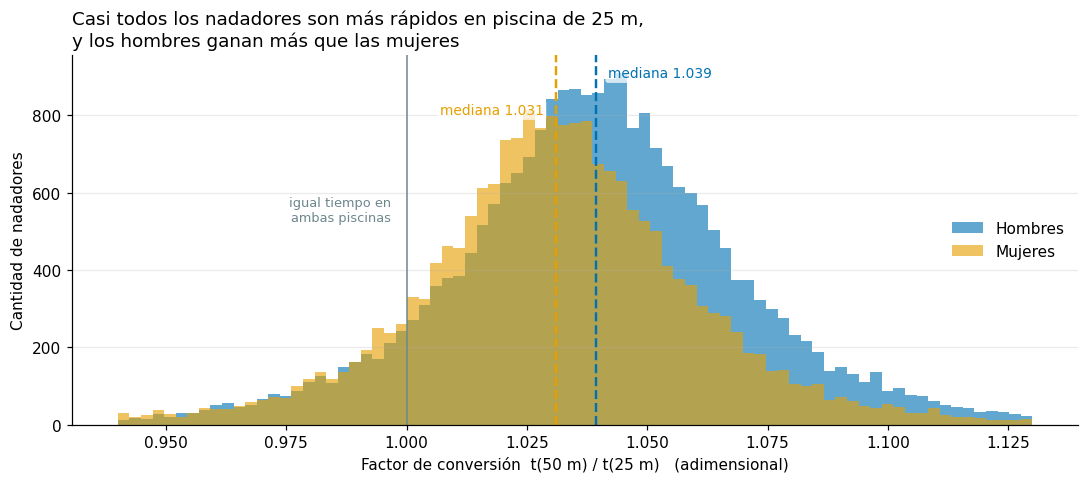

In [58]:
fig, ax = plt.subplots(figsize=(10, 4.5))
bordes = np.linspace(0.94, 1.13, 80)
alturas = {"M": .97, "F": .87}          # alturas distintas: si no, las etiquetas se pisan
lados   = {"M": (8, "left"), "F": (-8, "right")}
for sexo, color, nom in [("M", "#0072B2", "Hombres"), ("F", "#E69F00", "Mujeres")]:
    v = pares.loc[pares["sexo"] == sexo, "factor_tiempo_mediana"]
    ax.hist(v, bins=bordes, alpha=.62, color=color, label=nom, edgecolor="none")
    ax.axvline(v.median(), color=color, linestyle="--", linewidth=1.6)
    dx, ha = lados[sexo]
    ax.annotate(f"mediana {v.median():.3f}", (v.median(), alturas[sexo]),
                xycoords=("data", "axes fraction"), xytext=(dx, 0),
                textcoords="offset points", color=color, fontsize=9, ha=ha, va="top",
                bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=.75,
                          edgecolor="none"))

ax.axvline(1.0, color=GRIS, linewidth=1)
ax.annotate("igual tiempo en\nambas piscinas", (1.0, .55), xycoords=("data", "axes fraction"),
            xytext=(-10, 0), textcoords="offset points", color=GRIS, fontsize=8.5, ha="right")
ax.set_xlabel("Factor de conversión  t(50 m) / t(25 m)   (adimensional)")
ax.set_ylabel("Cantidad de nadadores")
ax.set_title("Casi todos los nadadores son más rápidos en piscina de 25 m,\n"
             "y los hombres ganan más que las mujeres", fontsize=12, loc="left")
ax.legend(frameon=False, loc="center right")
ax.grid(axis="y", alpha=.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

La masa está a la derecha de 1,0: la piscina corta es más rápida para casi todo el
mundo. Las dos distribuciones tienen forma parecida y están **desplazadas**: la de
los hombres, a la derecha. La cola izquierda —los que fueron más rápidos en 50 m—
es la del 13,5% que documentamos en la sección 1.5.

## 4.2 Boxplot — la dispersión detrás de cada mediana

*Objetivo: las tablas muestran medianas; hace falta ver cuánta variación hay entre
nadadores de una misma prueba, para no leer la mediana como si fuera una constante
física.*

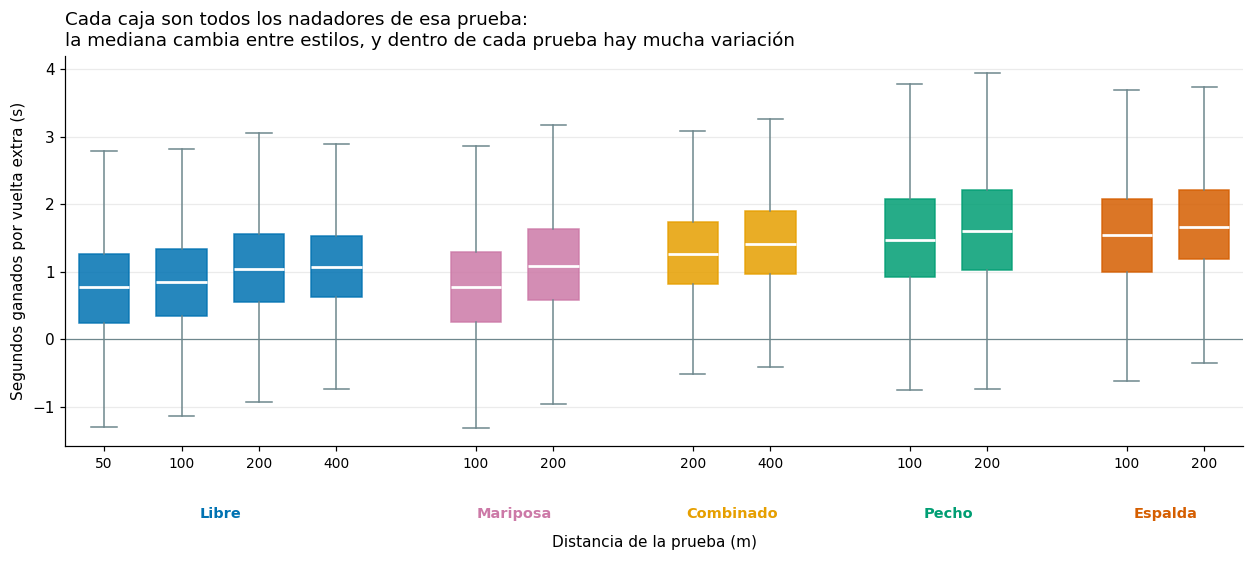

In [59]:
fig, ax = plt.subplots(figsize=(11.5, 5.2))
etiquetas, posiciones, datos, colores = [], [], [], []
grupos = []          # centro de cada estilo, para rotularlo bajo el eje
p = 0
for estilo in ORDEN:
    inicio = p
    for dist in sorted(pares.loc[pares["estilo"] == estilo, "distancia"].unique()):
        v = pares.loc[(pares["estilo"] == estilo) & (pares["distancia"] == dist), "por_vuelta_tiempo_mediana"]
        if len(v) < 30:
            continue
        datos.append(v.values); posiciones.append(p); colores.append(COLORES[estilo])
        etiquetas.append(f"{dist}"); p += 1
    grupos.append(((inicio + p - 1) / 2, NOMBRES[estilo], COLORES[estilo]))
    p += 0.8

bp = ax.boxplot(datos, positions=posiciones, widths=.65, patch_artist=True,
                showfliers=False, medianprops=dict(color="white", linewidth=1.8))
for caja, c in zip(bp["boxes"], colores):
    caja.set(facecolor=c, edgecolor=c, alpha=.85)
for parte in ["whiskers", "caps"]:
    for art in bp[parte]:
        art.set(color=GRIS, linewidth=1)

ax.set_xticks(posiciones); ax.set_xticklabels(etiquetas, fontsize=9)
# Etiqueta directa del estilo: el color solo no basta para distinguir
# Mariposa de Pecho en visión con deficiencia de rojo-verde.
for x, nombre, c in grupos:
    ax.annotate(nombre, (x, -0.155), xycoords=("data", "axes fraction"),
                ha="center", va="top", fontsize=9.5, color=c, fontweight="bold")
ax.set_xlabel("Distancia de la prueba (m)", labelpad=42)
ax.set_ylabel("Segundos ganados por vuelta extra (s)")
ax.set_title("Cada caja son todos los nadadores de esa prueba:\n"
             "la mediana cambia entre estilos, y dentro de cada prueba hay mucha variación",
             fontsize=12, loc="left")
ax.axhline(0, color=GRIS, linewidth=.8)
ax.grid(axis="y", alpha=.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Las cajas se desplazan hacia arriba de izquierda a derecha —el orden de estilos de
la sección 3.4— pero **se superponen mucho**: la ventaja por vuelta de un nadador
concreto de libre puede ser mayor que la de uno de espalda. El patrón es de
poblaciones, no de individuos, y así hay que enunciarlo en el informe.

## 4.3 Dispersión con overplotting tratado — las dos marcas del mismo nadador

*Objetivo: mirar el dato crudo del que sale todo. Son 30.257 puntos sobre cuatro
distancias muy distintas: hay saturación y colas largas, así que se usan hexágonos
con conteo en escala logarítmica y ejes también logarítmicos.*

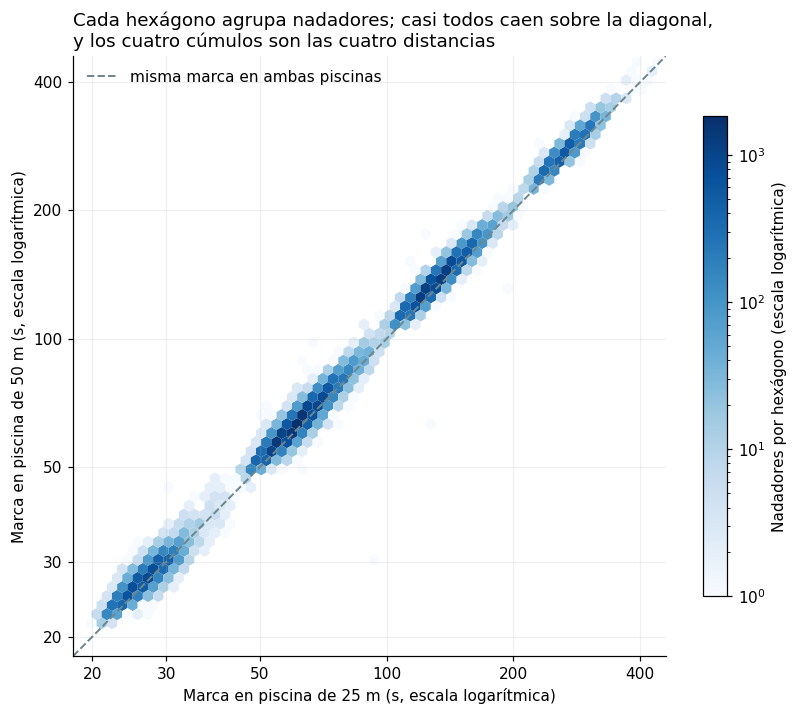

In [60]:
fig, ax = plt.subplots(figsize=(7.6, 6.6))
hb = ax.hexbin(pares["tiempo_mediana_scm"], pares["tiempo_mediana_lcm"],
               gridsize=55, bins="log", xscale="log", yscale="log",
               cmap="Blues", mincnt=1, linewidths=0)
lim = [18, 460]
ax.plot(lim, lim, color=GRIS, linestyle="--", linewidth=1.3,
        label="misma marca en ambas piscinas")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Marca en piscina de 25 m (s, escala logarítmica)")
ax.set_ylabel("Marca en piscina de 50 m (s, escala logarítmica)")
ax.set_title("Cada hexágono agrupa nadadores; casi todos caen sobre la diagonal,\n"
             "y los cuatro cúmulos son las cuatro distancias", fontsize=12, loc="left")
from matplotlib.ticker import FixedLocator, FixedFormatter
marcas = [20, 30, 50, 100, 200, 400]
for eje in (ax.xaxis, ax.yaxis):
    eje.set_major_locator(FixedLocator(marcas))
    eje.set_major_formatter(FixedFormatter([str(m) for m in marcas]))
    eje.set_minor_locator(FixedLocator([]))
cb = fig.colorbar(hb, ax=ax, shrink=.8)
cb.set_label("Nadadores por hexágono (escala logarítmica)")
ax.legend(frameon=False, loc="upper left")
ax.grid(alpha=.2, which="both")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Sin el tratamiento —hexágonos, conteo en log y ejes en log— esto sería una mancha
negra en la esquina inferior izquierda con cuatro puntos sueltos arriba. Así se ve
lo que importa: los cuatro cúmulos son las cuatro distancias, y **la nube está
íntegra por encima de la diagonal**, es decir, la marca de 50 m es más lenta. La
separación respecto de la diagonal es tan pequeña en escala logarítmica que ya
adelanta algo: el efecto es de un 3%, no de un 30%.

## 4.4 Líneas — la prueba de la hipótesis, gráfica

*Objetivo: la hipótesis dice que si cada vuelta valiera lo mismo, estas líneas
serían planas y estarían encima unas de otras. Basta mirarlas.*

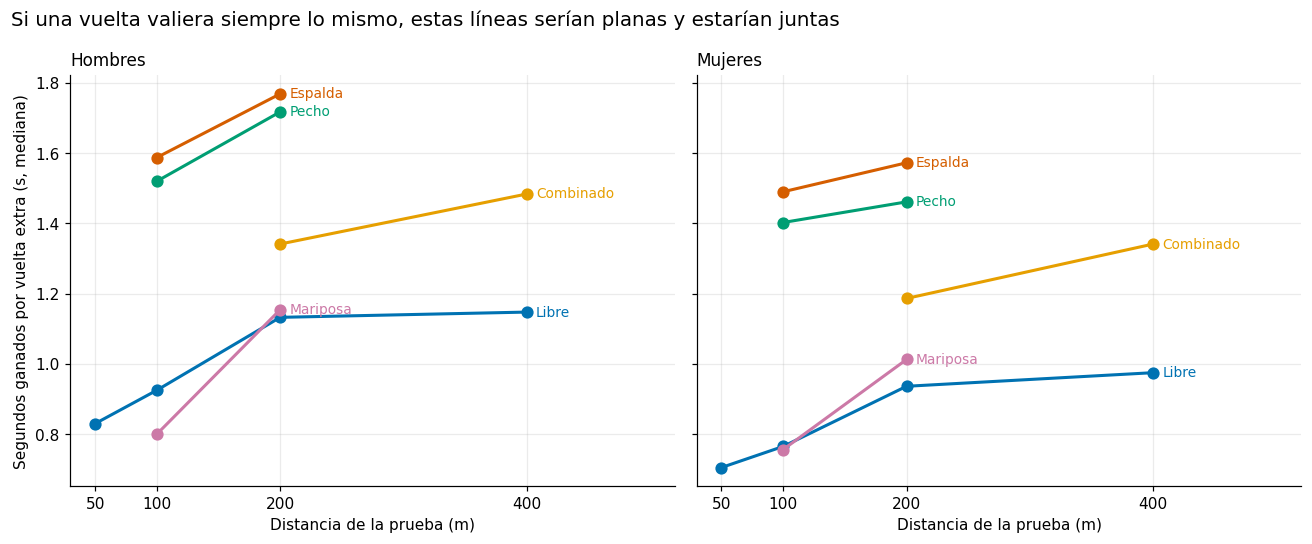

In [61]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, sexo, titulo in zip(ejes, ["M", "F"], ["Hombres", "Mujeres"]):
    d = pares[pares["sexo"] == sexo]
    for estilo in ORDEN:
        s = d[d["estilo"] == estilo].groupby("distancia")["por_vuelta_tiempo_mediana"].median()
        if s.empty:
            continue
        ax.plot(s.index, s.values, marker="o", markersize=7, linewidth=2,
                color=COLORES[estilo], label=NOMBRES[estilo])
        ax.annotate(NOMBRES[estilo], (s.index[-1], s.values[-1]),
                    xytext=(6, 0), textcoords="offset points",
                    color=COLORES[estilo], fontsize=9, va="center")
    ax.set_title(titulo, fontsize=11, loc="left")
    ax.set_xlabel("Distancia de la prueba (m)")
    ax.set_xticks([50, 100, 200, 400])
    ax.grid(alpha=.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.set_xlim(30, 520)

ejes[0].set_ylabel("Segundos ganados por vuelta extra (s, mediana)")
fig.suptitle("Si una vuelta valiera siempre lo mismo, estas líneas serían planas y estarían juntas",
             fontsize=13, x=0.01, ha="left")
plt.tight_layout()
plt.show()

Ni planas ni juntas: espalda y pecho van arriba, mariposa abajo, y todas suben con
la distancia. **El mismo orden en los dos paneles.** La hipótesis del modelo simple
queda descartada por partida doble: la ventaja por vuelta depende del estilo y
depende de la distancia.

## 4.5 Barras — lo medido contra lo que exige la federación

*Objetivo: traducir el hallazgo a la decisión que motiva el proyecto. La razón entre
las dos marcas mínimas de World Aquatics es la equivalencia que la federación aplica
de hecho; la comparamos con la medida.*

Las mínimas están transcritas del documento oficial de clasificación al Mundial de
25 m de Beijing 2026 y se calculan en `factor_implicito_wa.py`.

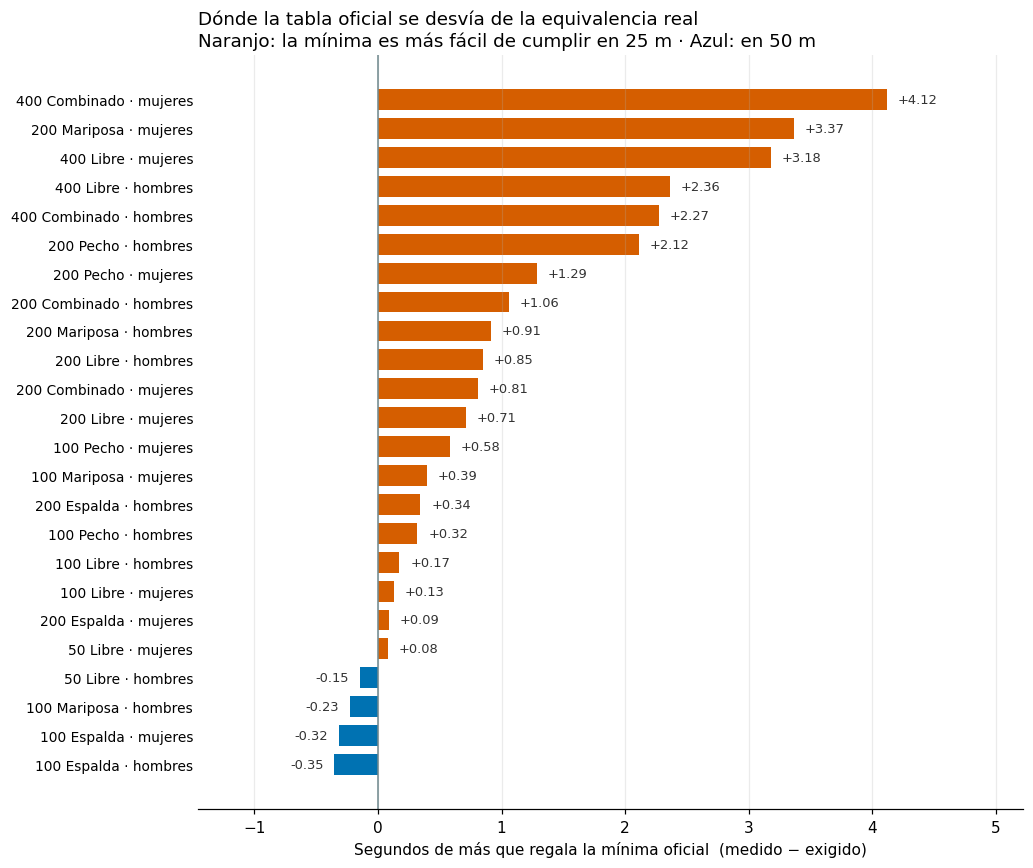

In [63]:
comp = pd.read_csv("datos/comparacion_wa.csv")
comp["etiqueta"] = comp["prueba"] + " · " + comp["sexo"].map({"M": "hombres", "F": "mujeres"})
comp = comp.sort_values("brecha_s")

AZUL, NARANJA = "#0072B2", "#D55E00"
colores_b = np.where(comp["brecha_s"] >= 0, NARANJA, AZUL)

fig, ax = plt.subplots(figsize=(9.5, 8))
ax.barh(comp["etiqueta"], comp["brecha_s"], color=colores_b, height=.72)
ax.axvline(0, color=GRIS, linewidth=1)
for y, (v, et) in enumerate(zip(comp["brecha_s"], comp["etiqueta"])):
    ax.annotate(f"{v:+.2f}", (v, y), xytext=(7 if v >= 0 else -7, 0),
                textcoords="offset points", va="center",
                ha="left" if v >= 0 else "right", fontsize=8.5, color="#333333")
ax.set_xlabel("Segundos de más que regala la mínima oficial  (medido − exigido)")
ax.set_title("Dónde la tabla oficial se desvía de la equivalencia real\n"
             "Naranjo: la mínima es más fácil de cumplir en 25 m · Azul: en 50 m",
             fontsize=12, loc="left")
ax.set_xlim(comp["brecha_s"].min() - 1.1, comp["brecha_s"].max() + 1.1)
ax.grid(axis="x", alpha=.25)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0, labelsize=9)
plt.tight_layout()
plt.show()

In [64]:
print(f"Pruebas más fáciles de clasificar en 25 m: {(comp['brecha_s'] > 0).sum()}")
print(f"Pruebas más fáciles de clasificar en 50 m: {(comp['brecha_s'] < 0).sum()}")
print(f"Brecha absoluta mediana: {comp['brecha_s'].abs().median():.2f} s")
print(f"Pruebas con brecha menor a 0,3 s: {(comp['brecha_s'].abs() < 0.3).sum()} de {len(comp)}")
r_wa = comp[["factor_wa_A", "factor_real"]].corr().iloc[0, 1]
print(f"\nCorrelación entre el factor oficial y el medido: {r_wa:.3f}")

Pruebas más fáciles de clasificar en 25 m: 20
Pruebas más fáciles de clasificar en 50 m: 4
Brecha absoluta mediana: 0.65 s
Pruebas con brecha menor a 0,3 s: 6 de 24

Correlación entre el factor oficial y el medido: 0.810


**Interpretación, con cuidado.** La correlación de 0,81 entre ambos factores dice
que la tabla oficial **no es arbitraria**: captura la tendencia por estilo. En 6 de
las 24 pruebas la brecha es menor a 0,3 s, que es ruido para efectos prácticos. Y
las desviaciones no apuntan todas al mismo lado: 20 pruebas son más fáciles en 25 m
y 4 en 50 m.

Lo que los datos muestran, entonces, no es "la tabla está mal calibrada" sino que
**se desvía de forma inconsistente en un subconjunto de pruebas**, con casos como
los 400 combinado o los 200 mariposa femeninos donde la diferencia supera los
3,37 s. Esa es una afirmación que los datos sostienen; la otra, no.

---
# 5. Hallazgos y siguientes pasos

In [66]:
extremos = (pares.groupby(["sexo", "estilo", "distancia"])["factor_tiempo_mediana"].median()
                 .sort_values())
print("Las tres pruebas con menor factor:")
for (s, e, d), v in extremos.head(3).items():
    print(f"   {d:3d} {NOMBRES[e]:10} {'hombres' if s=='M' else 'mujeres':8} {v:.4f}")
print("\nLas tres pruebas con mayor factor:")
for (s, e, d), v in extremos.tail(3).items():
    print(f"   {d:3d} {NOMBRES[e]:10} {'hombres' if s=='M' else 'mujeres':8} {v:.4f}")
print(f"\nRango completo: {extremos.min():.4f} a {extremos.max():.4f}")
print(f"La ventaja de nadar en piscina corta va de {(extremos.min()-1)*100:.1f}% a "
      f"{(extremos.max()-1)*100:.1f}% del tiempo total, según la prueba: "
      f"{(extremos.max()-1)/(extremos.min()-1):.1f} veces más en una que en otra.")

Las tres pruebas con menor factor:
   100 Mariposa   mujeres  1.0231
    50 Libre      mujeres  1.0252
   100 Libre      mujeres  1.0256

Las tres pruebas con mayor factor:
   200 Pecho      hombres  1.0492
   100 Espalda    hombres  1.0546
   200 Espalda    hombres  1.0562

Rango completo: 1.0231 a 1.0562
La ventaja de nadar en piscina corta va de 2.3% a 5.6% del tiempo total, según la prueba: 2.4 veces más en una que en otra.


## Los cinco hallazgos

1. **El factor de conversión entre piscina de 25 y 50 m no es una constante: va de
   1,023 a 1,056 según la prueba**, es decir, la ventaja de nadar en piscina corta
   varía en un factor de más de tres entre la prueba donde menos importa (100 m
   mariposa femenino) y aquella donde más (200 m espalda masculino). Cualquier
   calculadora que use un único número está equivocada en la mayoría de las pruebas.

2. **La hipótesis del modelo simple —cada vuelta extra vale lo mismo— queda
   descartada.** Si fuera cierta, los segundos ganados por vuelta serían iguales
   entre estilos y distancias; medidos sobre 43.914 pares, crecen con la distancia
   en los diez casos donde hay más de una distancia, y siguen el mismo orden de
   estilos en hombres y mujeres (mariposa < libre < combinado < pecho < espalda).
   Que el orden se repita en dos poblaciones independientes indica que responde a la
   mecánica del nado y no al ruido de la muestra.

3. **Los hombres se benefician más de la piscina corta que las mujeres en las doce
   pruebas comparadas, sin excepción**, con diferencias de 0,6 a 1,2 puntos
   porcentuales, significativas en todas (Mann-Whitney; el mayor de los doce
   valores p es 2,4e-8). Este resultado
   contradice a Iglesias García et al. (2025), que reporta diferencias mínimas por
   sexo sobre los rankings españoles, y coincide con el análisis de récords de Curl
   (2014).

4. **La equivalencia implícita en las marcas mínimas de World Aquatics captura la
   tendencia por estilo (correlación 0.81 con el factor medido), pero se desvía de
   forma inconsistente en un subconjunto de pruebas.** En 6 de 24 pruebas la brecha
   es menor a 0,3 s, pero en los 400 m combinado y los 200 m mariposa femeninos
   supera los 3,37 s; y 20 pruebas resultan más fáciles de clasificar en 25 m contra
   4 en 50 m. La consecuencia práctica para un nadador es que **la piscina en la
   que conviene intentar la mínima depende de su prueba**.

5. **El aparente efecto del nivel del nadador sobre el factor es un artefacto de
   selección, no un fenómeno.** Al ser el factor un cociente, definir "élite" por el
   tiempo de uno de los dos lados mueve la mediana casi un punto porcentual sin que
   cambie ningún nadador; con una definición neutral el efecto cae hasta volverse
   irrelevante (rho de Spearman +0,003 contra  −0,167 del criterio sesgado:
   significativo por el tamaño de la muestra, sin importancia práctica). El
   hallazgo importa porque valida comparar nuestra mediana poblacional con una tabla
   de marcas mínimas de nivel más alto.

## El modelo que viene

El análisis exploratorio deja planteada una regresión que se ajustará en el informe
de avance:

$$\text{diferencia\_s} = \beta_0 + \beta_1 \cdot \text{vueltas\_extra} + \varepsilon$$

estimada **por estilo y sexo** (equivalentemente, un modelo múltiple con la
interacción `vueltas_extra × estilo`, que es lo trabajado en la clase 4 con variables
dummy). La lectura es directa:

- **La pendiente $\beta_1$ es la ventaja por vuelta** de ese estilo, con su intervalo
  de confianza. Comparar pendientes entre estilos es la forma formal de la pregunta.
- **El intercepto $\beta_0$ dice si hay algo más en juego además de las vueltas.**
  Si el modelo simple fuera correcto, debería ser cero: sin vueltas extra, no hay
  diferencia. Un intercepto significativamente distinto de cero apuntaría a un
  segundo mecanismo (la salida, o el desgaste distinto entre calendarios).

Con las herramientas de la clase 5 se agregarán además **intervalos de confianza
para el factor de cada prueba** —hoy sólo tenemos la mediana puntual— y una prueba
de hipótesis formal para la brecha entre sexos. Con las de la clase 7, una regresión
regularizada para comprobar que las conclusiones no dependen de las pruebas con
menos pares.

## Limitaciones declaradas

1. La muestra son los mejores resultados mensualmente por nadador de cada prueba, no una muestra aleatoria:
   describe el mejor rendimiento de la élite competitiva, no todos los nados de la población de nadadores.
2. Un nadador puede estar en distinta forma en la temporada de piscina corta y en la
   de larga; el diseño dentro-nadador no elimina eso, sólo lo promedia sobre miles
   de casos. Es el origen del 13,5% de pares con la piscina de 50 m más rápida.
3. Un solo año (2024). Ampliable editando `ANIOS` en `descarga_temporada.py`.
4. Los términos legales de World Aquatics prohíben la extracción automatizada y la
   redistribución de sus contenidos. El uso aquí es académico, con pausa entre
   peticiones y caché local, y **no se redistribuyen los datos crudos**.